# Homework solution PyTorch Diabetes

https://www.kaggle.com/uciml/pima-indians-diabetes-database/data

## Loading the dataset

In [1]:
import torch
torch.__version__

'2.12.0'

In [2]:
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import torch.nn as nn

In [3]:
import os
# Load from the notebook's own directory (works regardless of CWD)
_nb_dir = os.path.dirname(os.path.abspath('10_pytorch_diabetes.ipynb'))
diabetes = pd.read_csv(os.path.join(_nb_dir, 'diabetes.csv'))


In [4]:
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
inputs = diabetes.iloc[:, 0:8].values
inputs.shape

(768, 8)

In [6]:
inputs

array([[  6.   , 148.   ,  72.   , ...,  33.6  ,   0.627,  50.   ],
       [  1.   ,  85.   ,  66.   , ...,  26.6  ,   0.351,  31.   ],
       [  8.   , 183.   ,  64.   , ...,  23.3  ,   0.672,  32.   ],
       ...,
       [  5.   , 121.   ,  72.   , ...,  26.2  ,   0.245,  30.   ],
       [  1.   , 126.   ,  60.   , ...,  30.1  ,   0.349,  47.   ],
       [  1.   ,  93.   ,  70.   , ...,  30.4  ,   0.315,  23.   ]],
      shape=(768, 8))

In [7]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
inputs = scaler.fit_transform(inputs)

In [8]:
inputs

array([[0.35294118, 0.74371859, 0.59016393, ..., 0.50074516, 0.23441503,
        0.48333333],
       [0.05882353, 0.42713568, 0.54098361, ..., 0.39642325, 0.11656704,
        0.16666667],
       [0.47058824, 0.91959799, 0.52459016, ..., 0.34724292, 0.25362938,
        0.18333333],
       ...,
       [0.29411765, 0.6080402 , 0.59016393, ..., 0.390462  , 0.07130658,
        0.15      ],
       [0.05882353, 0.63316583, 0.49180328, ..., 0.4485842 , 0.11571307,
        0.43333333],
       [0.05882353, 0.46733668, 0.57377049, ..., 0.45305514, 0.10119556,
        0.03333333]], shape=(768, 8))

In [9]:
outputs = diabetes.iloc[:,8].values
outputs

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,

In [10]:
X_train, X_test, y_train, y_test = train_test_split(inputs, outputs, test_size = 0.20)

In [11]:
X_train.shape

(614, 8)

In [12]:
X_test.shape

(154, 8)

## Data transformation


In [13]:
type(X_train)

numpy.ndarray

In [14]:
X_train = torch.tensor(X_train, dtype=torch.float)
y_train = torch.tensor(y_train, dtype = torch.float)

In [15]:
type(X_train)

torch.Tensor

In [16]:
dataset = torch.utils.data.TensorDataset(X_train, y_train)

In [17]:
type(dataset)

torch.utils.data.dataset.TensorDataset

In [18]:
train_loader = torch.utils.data.DataLoader(dataset, batch_size=10)

## Neural network structure

In [19]:
(8 + 1) / 2

4.5

In [20]:
# 8 -> 5 -> 5 -> 1
network = nn.Sequential(nn.Linear(8, 5),
                          nn.Sigmoid(),
                          nn.Linear(5, 5),
                          nn.Sigmoid(),
                          nn.Linear(5, 1),
                          nn.Sigmoid())

In [21]:
network.parameters

<bound method Module.parameters of Sequential(
  (0): Linear(in_features=8, out_features=5, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=5, out_features=5, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=5, out_features=1, bias=True)
  (5): Sigmoid()
)>

In [22]:
loss_function = nn.BCELoss()

In [23]:
optimizer = torch.optim.Adam(network.parameters(), lr=0.01)

In [24]:
epochs = 2000
for epoch in range(epochs):
  running_loss = 0.

  for data in train_loader:
    inputs, outputs = data
    optimizer.zero_grad()

    predictions = network.forward(inputs)
    # squeeze (batch,1) → (batch,) to match targets shape for BCELoss
    loss = loss_function(predictions.squeeze(), outputs)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
  if (epoch + 1) % 200 == 0:
    print('Epoch %4d: loss %.5f' % (epoch+1, running_loss/len(train_loader)))


Epoch  200: loss 0.44893


Epoch  400: loss 0.44114


Epoch  600: loss 0.43733


Epoch  800: loss 0.43343


Epoch 1000: loss 0.42741


Epoch 1200: loss 0.41904


Epoch 1400: loss 0.40702


Epoch 1600: loss 0.39543


Epoch 1800: loss 0.38488


Epoch 2000: loss 0.37724


## Evaluate

In [25]:
network.eval()

Sequential(
  (0): Linear(in_features=8, out_features=5, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=5, out_features=5, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=5, out_features=1, bias=True)
  (5): Sigmoid()
)

In [26]:
X_test = torch.tensor(X_test, dtype=torch.float)

In [27]:
with torch.no_grad():
    predictions = network.forward(X_test)
predictions


tensor([[2.1053e-01],
        [8.2618e-01],
        [2.0276e-01],
        [2.1679e-03],
        [5.0356e-02],
        [5.8962e-01],
        [8.6513e-01],
        [7.9702e-02],
        [3.1841e-01],
        [2.6797e-01],
        [9.8111e-02],
        [9.0741e-09],
        [1.1915e-07],
        [8.7954e-05],
        [2.3374e-01],
        [1.9593e-01],
        [1.9945e-01],
        [1.1065e-01],
        [4.3666e-07],
        [1.3769e-01],
        [8.0906e-01],
        [1.8869e-01],
        [7.0584e-02],
        [7.8137e-08],
        [8.4924e-01],
        [2.2015e-01],
        [1.7282e-01],
        [8.4532e-01],
        [2.4399e-03],
        [6.9334e-01],
        [2.1350e-01],
        [2.6820e-01],
        [2.1228e-07],
        [2.8600e-01],
        [1.9010e-01],
        [2.1616e-03],
        [3.0141e-08],
        [2.1281e-01],
        [1.1282e-01],
        [1.6124e-06],
        [8.8153e-01],
        [2.4661e-01],
        [2.6144e-08],
        [2.6390e-01],
        [1.9214e-01],
        [1

In [28]:
predictions

tensor([[2.1053e-01],
        [8.2618e-01],
        [2.0276e-01],
        [2.1679e-03],
        [5.0356e-02],
        [5.8962e-01],
        [8.6513e-01],
        [7.9702e-02],
        [3.1841e-01],
        [2.6797e-01],
        [9.8111e-02],
        [9.0741e-09],
        [1.1915e-07],
        [8.7954e-05],
        [2.3374e-01],
        [1.9593e-01],
        [1.9945e-01],
        [1.1065e-01],
        [4.3666e-07],
        [1.3769e-01],
        [8.0906e-01],
        [1.8869e-01],
        [7.0584e-02],
        [7.8137e-08],
        [8.4924e-01],
        [2.2015e-01],
        [1.7282e-01],
        [8.4532e-01],
        [2.4399e-03],
        [6.9334e-01],
        [2.1350e-01],
        [2.6820e-01],
        [2.1228e-07],
        [2.8600e-01],
        [1.9010e-01],
        [2.1616e-03],
        [3.0141e-08],
        [2.1281e-01],
        [1.1282e-01],
        [1.6124e-06],
        [8.8153e-01],
        [2.4661e-01],
        [2.6144e-08],
        [2.6390e-01],
        [1.9214e-01],
        [1

In [29]:
predictions = (predictions.squeeze() >= 0.5)
predictions


tensor([False,  True, False, False, False,  True,  True, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
         True, False, False, False,  True, False, False,  True, False,  True,
        False, False, False, False, False, False, False, False, False, False,
         True, False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False,  True,  True, False,  True,
         True,  True, False, False, False,  True,  True, False,  True, False,
         True, False,  True, False, False, False,  True, False,  True, False,
        False, False, False, False, False,  True, False,  True, False, False,
         True, False, False, False,  True, False,  True, False, False, False,
        False, False, False, False,  True,  True, False, False, False, False,
        False, False, False, False,  True,  True, False, False,  True,  True,
        False,  True, False, False, False, False, False, False, 

In [30]:
y_test

array([0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0])

In [31]:
accuracy_score(y_test, predictions.detach().numpy())

0.7272727272727273

In [32]:
cm = confusion_matrix(y_test, predictions.detach().numpy())
cm

array([[87, 16],
       [26, 25]])

<Axes: >

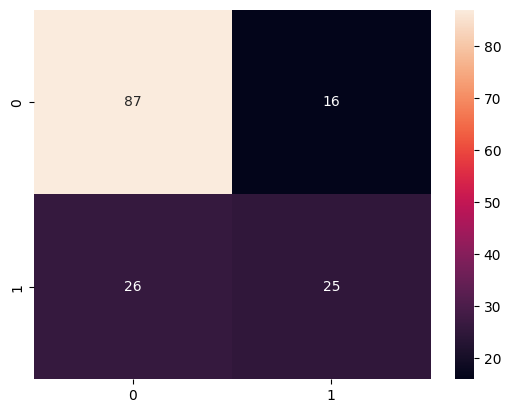

In [33]:
import seaborn as sns
sns.heatmap(cm, annot=True)